# Лекция 4. Атаки уклонения: FGSM

Демонстрация: реализация FGSM-атаки на CNN, визуализация возмущения, влияние epsilon.

## 1. Загрузка обученной модели (используем MNIST CNN как в лекции 3)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)
np.random.seed(0)

import torchvision
import torchvision.transforms as T

transform = T.Compose([T.ToTensor()])
test_ds = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=1, shuffle=True)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.fc = nn.Linear(32*7*7,10)
    def forward(self,x):
        x = F.relu(self.conv1(x)); x = F.max_pool2d(x,2)
        x = F.relu(self.conv2(x)); x = F.max_pool2d(x,2)
        x = x.view(x.size(0),-1)
        return self.fc(x)

train_ds = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)
model = SimpleCNN()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for i,(xb,yb) in enumerate(train_loader):
    opt.zero_grad(); loss = F.cross_entropy(model(xb), yb); loss.backward(); opt.step()
    if i>=300: break
print("Модель обучена, loss:", loss.item())


Модель обучена, loss: 0.11312925815582275


## 2. Реализация FGSM

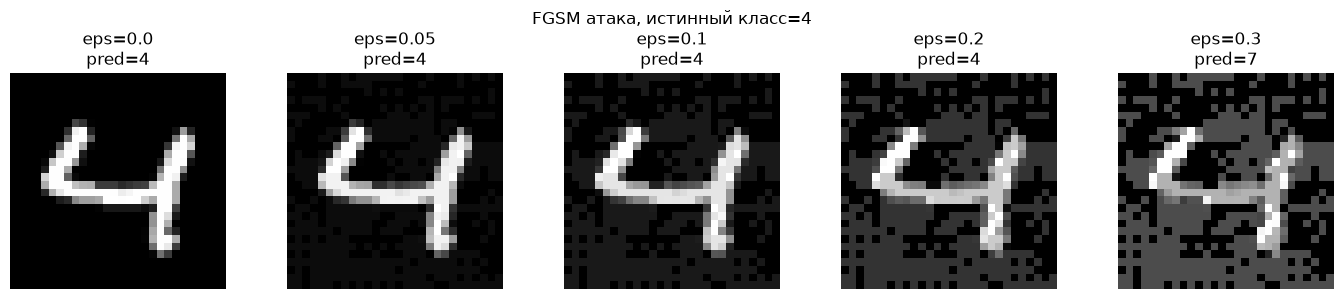

In [2]:

def fgsm_attack(model, x, y, eps):
    x = x.clone().detach().requires_grad_(True)
    out = model(x)
    loss = F.cross_entropy(out, y)
    loss.backward()
    x_adv = x + eps * x.grad.sign()
    return torch.clamp(x_adv, 0, 1).detach()

x, y = next(iter(test_loader))
pred_clean = model(x).argmax(1)

fig, axes = plt.subplots(1,5, figsize=(14,3))
for i, eps in enumerate([0.0, 0.05, 0.1, 0.2, 0.3]):
    x_adv = fgsm_attack(model, x, y, eps)
    pred = model(x_adv).argmax(1).item()
    axes[i].imshow(x_adv[0,0].detach().numpy(), cmap='gray')
    axes[i].set_title(f"eps={eps}\npred={pred}")
    axes[i].axis('off')
plt.suptitle(f"FGSM атака, истинный класс={y.item()}")
plt.tight_layout()
plt.savefig('output/notebooks/lec4_fgsm.png', dpi=120)
plt.show()


## 3. Attack Success Rate в зависимости от epsilon

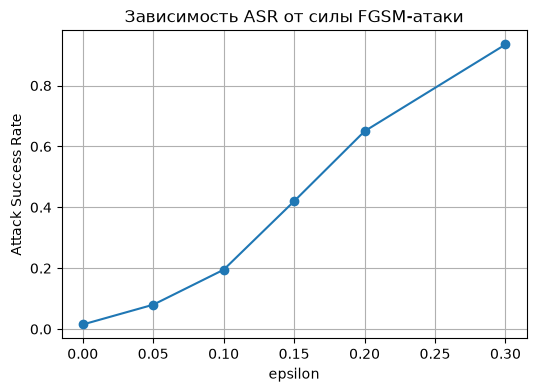

[(0.0, 0.015), (0.05, 0.08), (0.1, 0.195), (0.15, 0.42), (0.2, 0.65), (0.3, 0.935)]


In [3]:

def evaluate_asr(model, loader, eps, n=200):
    success = 0; total = 0
    for i, (x,y) in enumerate(loader):
        if i>=n: break
        x_adv = fgsm_attack(model, x, y, eps)
        pred = model(x_adv).argmax(1)
        if pred.item() != y.item():
            success += 1
        total += 1
    return success/total

eps_list = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]
asrs = [evaluate_asr(model, test_loader, e) for e in eps_list]
plt.figure(figsize=(6,4))
plt.plot(eps_list, asrs, marker='o')
plt.xlabel("epsilon"); plt.ylabel("Attack Success Rate")
plt.title("Зависимость ASR от силы FGSM-атаки")
plt.grid(True)
plt.savefig('output/notebooks/lec4_asr.png', dpi=120)
plt.show()
print(list(zip(eps_list, asrs)))
